In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/raw/comptages.csv", sep=";") 

In [3]:
#Nombre de lignes
len(df)

200744

In [4]:
# Haut du tableau
df.head()

,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,5871,Bd_Macdonald,2026-08-31T23:00:00+00:00,94.0,NaN,Inconnu,3048,Bd Macdonald-Allee des Cardinoux,928,Bd_Macdonald - Jaques Duchesne,Ouvert
1,1744,Bd_Macdonald,2026-08-31T23:00:00+00:00,94.0,0.52500,Fluide,928,Bd_Macdonald - Jaques Duchesne,929,Bd_Macdonald - Lounes Matoub,Ouvert
2,1745,Bd_Macdonald,2026-08-31T23:00:00+00:00,NaN,0.51833,Fluide,930,Bd_Macdonald - Chana Orloff,929,Bd_Macdonald - Lounes Matoub,Ouvert
3,1746,Bd_Macdonald,2026-08-31T23:00:00+00:00,48.0,NaN,Inconnu,929,Bd_Macdonald - Lounes Matoub,3630,Bd Macdonald - Rue E. 019,Ouvert
4,1747,Bd_Macdonald,2026-08-31T23:00:00+00:00,NaN,NaN,Inconnu,3630,Bd Macdonald - Rue E. 019,930,Bd_Macdonald - Chana Orloff,Invalide


In [5]:
# Informations sur le dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200744 entries, 0 to 200743
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   iu_ac             200744 non-null  int64  
 1   libelle           200744 non-null  object 
 2   t_1h              200744 non-null  object 
 3   q                 112709 non-null  float64
 4   k                 89777 non-null   float64
 5   etat_trafic       200744 non-null  object 
 6   iu_nd_amont       200744 non-null  int64  
 7   libelle_nd_amont  200744 non-null  object 
 8   iu_nd_aval        200744 non-null  int64  
 9   libelle_nd_aval   200744 non-null  object 
 10  etat_barre        200744 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 16.8+ MB


In [6]:
# Analyse statistique des colonnes q et k
df[['q', 'k']].describe()

,q,k
count,112709.000000,89777.000000
mean,186.483438,2.485795
std,115.066392,2.377445
min,0.000000,0.000000
25%,99.000000,1.058890
50%,174.000000,1.826110
75%,246.000000,3.226670
max,5036.950000,68.716670


In [7]:
# Nombre de valeurs null par colonne
df.isna().sum()

iu_ac                    0
libelle                  0
t_1h                     0
q                    88035
k                   110967
etat_trafic              0
iu_nd_amont              0
libelle_nd_amont         0
iu_nd_aval               0
libelle_nd_aval          0
etat_barre               0
dtype: int64

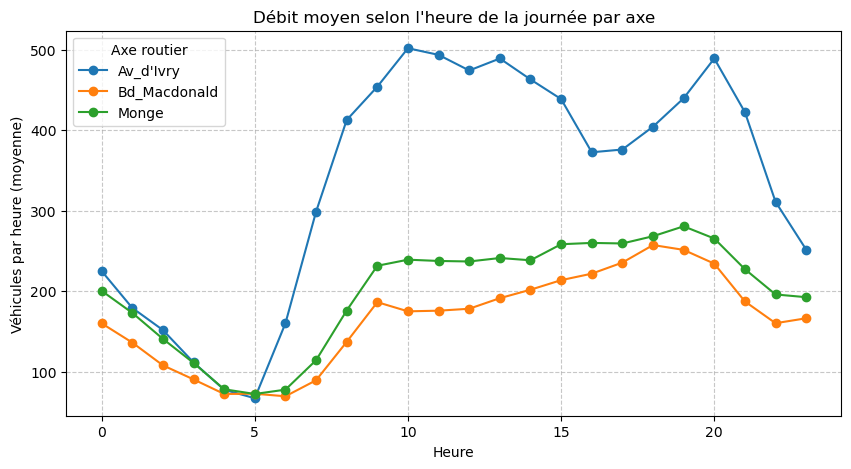

In [8]:
df["t_1h"] = pd.to_datetime(df["t_1h"])
df["heure"] = df["t_1h"].dt.tz_convert("Europe/Paris").dt.hour 

profil_axes = df.pivot_table(index="heure", columns="libelle", values="q", aggfunc="mean")

profil_axes.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Débit moyen selon l'heure de la journée par axe")
plt.xlabel("Heure")
plt.ylabel("Véhicules par heure (moyenne)")
plt.legend(title="Axe routier")
plt.grid(True, linestyle="--", alpha=0.7) 
plt.show()

Entre minuit et 5h, le trafic routier diminue, car il y a une baisse d'activité. Un fort pic à 5h, car la population part travailler, pour la plupart. On remarque des pics, à partir de 15h, ce qui pourrait être expliqué par, le retour de la population à leurs domiciles. 

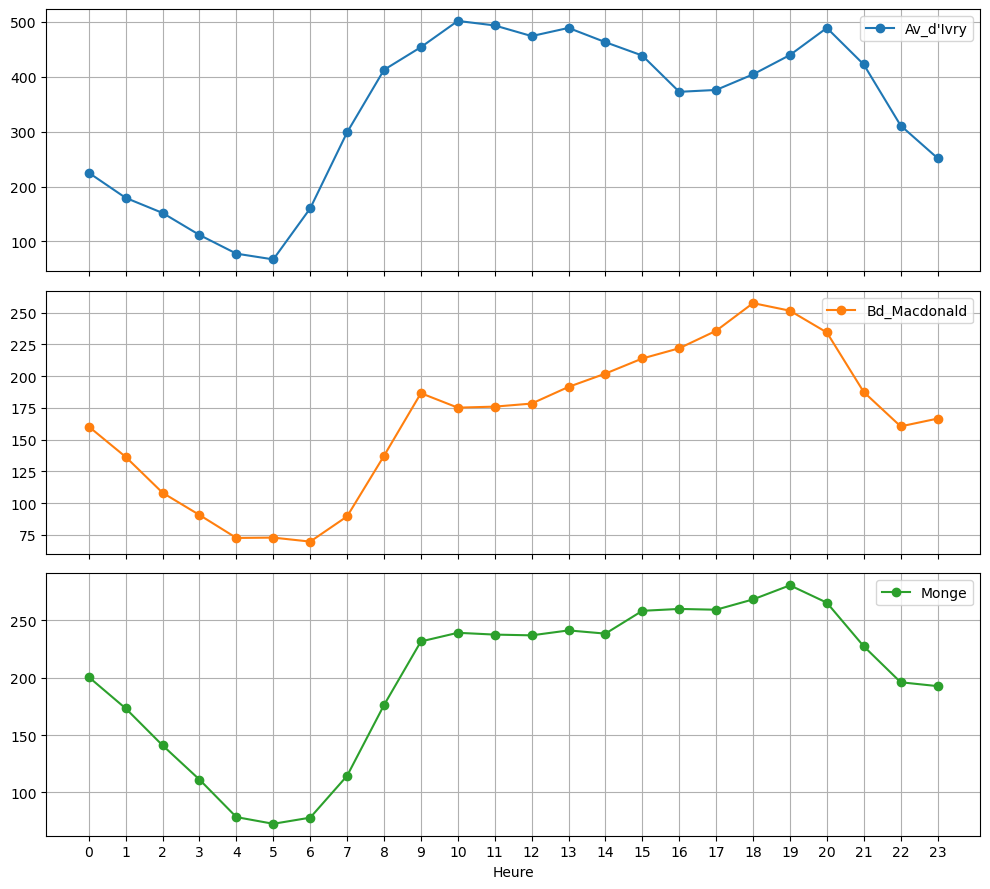

In [13]:
df["heure"] = df["t_1h"].dt.tz_convert("Europe/Paris").dt.hour
profil = df.groupby(["heure", "libelle"], observed=True)["q"].mean().unstack()

profil.plot(
    subplots=True,       
    figsize=(10, 9),     
    layout=(3, 1),      
    sharex=True,         
    sharey=False,        
    marker="o",
    grid=True           
)


plt.xlabel("Heure")
plt.xticks(range(0, 24)) # Force l'affichage de toutes les heures de 0 à 23

plt.tight_layout() 

plt.show()

Avenue d'Ivry : Présente un pic matinal, de 5h à 10h, avec un hausse de 300 véhicules par heure. On remarque un léger creux dans l'après-midi, de 15h à 20h. Puis la forte baisse à partir de 20H

Boulevard Macdonald : On remarque un long pic à partir de 6h, avec une très légère baisse 9h, jusqu'à 18h.

Monge : On remarque une augmentation continuelle à partir de 6h, jusqu'à 19h, pour par la suite baisser, de 100 véhicules par heure.